# Controlo Estatístico de Processo da Espessura de Revestimento em Várias Linhas de Produção com PROC BOXPLOT

## Resumo Executivo

Este notebook utiliza **PROC BOXPLOT** para realizar o controlo estatístico de processo (SPC) numa medição de espessura de revestimento crítica para a qualidade, recolhida em quatro linhas de produção paralelas. Geramos dados de medição sintéticos em linha, caracterizamos as linhas com `PROC MEANS` e desenhamos diagramas de caixa e bigodes esqueléticos e esquemáticos que comparam localização, dispersão e caudas entre as linhas num único gráfico.

Em seguida, avaliamos cada linha em relação à especificação de engenharia (alvo 50.00 mm, limites 49.80–50.20 mm) diretamente a partir do conjunto de dados de estatísticas **`OUTBOX=`** — os quartis exatos, as cercas e os extremos dos bigodes por detrás de cada caixa — e, por fim, demonstramos o ciclo completo **`OUTHISTORY=` / `HISTORY=`**: PROC BOXPLOT exporta uma linha de resumo compacta por linha de produção, e um segundo PROC BOXPLOT reconstrói um gráfico idêntico diretamente a partir desse resumo, o padrão que um painel de SPC diário utiliza para voltar a desenhar sem reanalisar as medições brutas.

Nas quatro linhas, **a LINE-A está mais bem centrada** no alvo (média 50.008 mm), **a LINE-C corre baixa** (média 49.932 mm, a desviar-se em direção ao LSL) e **a LINE-D corre simultaneamente alta e mais variável** (média 50.102 mm, desvio-padrão 0.080 mm) — o seu máximo de 50.248 mm é a única observação que ultrapassa o limite superior de especificação de 50.20 mm.

## Fontes de Dados

Todos os dados são sintéticos e gerados em linha pelo primeiro passo DATA usando `call streaminit(20250531)` e `rand()`. Não é utilizada qualquer entrada externa ou de rede. A semente fixa torna cada número deste notebook reproduzível.

**Conjunto de dados: `ProcessMeas`** (uma linha por peça medida)

| Variável | Tipo | Descrição |
|----------|------|-------------|
| `Line` | Char(6) | Identificador da linha de produção: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (a variável de grupo/classificação) |
| `Shift` | Num | Índice do turno de produção 1–6 (introduz uma ligeira deriva entre turnos) |
| `Thickness` | Num | Espessura de revestimento em mm (a variável de análise); alvo 50.00 mm, limites de especificação 49.80–50.20 mm |

Cada linha está centrada numa média ligeiramente diferente (50.00 / 50.04 / 49.92 / 50.10) com variação específica da linha, imitando diferenças reais de equipamento para equipamento, e a `LINE-B` injeta ocasionalmente uma pequena excursão positiva. O passo DATA percorre seis turnos e quatro linhas com tamanhos de subgrupo de aproximadamente 18–25 peças cada; neste ambiente sem licença o motor limita a saída às primeiras **100 observações**, o que aqui resulta em **38 / 19 / 21 / 22** peças para LINE-A até LINE-D — ainda amplo para preencher quatro caixas bem definidas.

# Controlo Estatístico de Processo da Espessura de Revestimento com PROC BOXPLOT

No fabrico de alto volume, um diagrama de caixa e bigodes é o cavalo de batalha do SPC de chão de fábrica: resume a tendência central, a dispersão e os valores atípicos de uma característica de qualidade para cada unidade de produção num único gráfico. Aqui monitorizamos a **espessura de revestimento (mm)** numa peça produzida em paralelo em quatro linhas (`LINE-A` até `LINE-D`). A especificação de engenharia é um alvo de **50.00 mm** com um limite inferior de especificação (LSL) de **49.80 mm** e um limite superior de especificação (USL) de **50.20 mm**.

Iremos:

1. Gerar um conjunto de dados de medição sintético em linha.
2. Caracterizar as linhas com `PROC MEANS`.
3. Desenhar um diagrama de caixa esquelético básico, depois um diagrama esquemático, sobrepondo os limites de especificação como linhas de referência.
4. Capturar cada estatística de caixa calculada com `OUTBOX=` e avaliar cada linha em relação aos limites de especificação a partir dessa tabela.
5. Persistir um resumo compacto de subgrupos com `OUTHISTORY=` e provar o ciclo completo voltando a desenhar diretamente a partir dele com `HISTORY=`.

## Passo 1 — Gerar medições de processo sintéticas

O passo DATA abaixo simula medições ao longo de seis turnos em quatro linhas. Cada linha está deliberadamente centrada numa média ligeiramente diferente com a sua própria variação, imitando diferenças reais de equipamento para equipamento, e uma ligeira deriva entre turnos é sobreposta com um termo `sin(Shift)`. Uma semente fixa (`streaminit(20250531)`) torna cada valor do notebook reproduzível.

In [1]:
DADOS ProcessMeas;
   CHAMAR streaminit(20250531);
   COMPRIMENTO Line $6;
   VETOR lines[4] $6 _temporary_ ('LINE-A' 'LINE-B' 'LINE-C' 'LINE-D');
   VETOR lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   VETOR LSD[4]     _temporary_ (0.045 0.060 0.050 0.085);
   RÓTULO Thickness='Coating Thickness (mm)';
   FAZER Shift = 1 ATÉ 6;
      FAZER li = 1 ATÉ 4;
         Line = lines[li];
         /* varying subgroup size per line/shift */
         n = 18 + floor(rand('uniform') * 8);
         FAZER u = 1 ATÉ n;
            BASE = lmean[li] + 0.012 * sin(Shift);
            Thickness = BASE + rand('normal') * LSD[li];
            /* LINE-B injects occasional high excursions */
            SE li = 2 E_LÓGICO rand('uniform') < 0.05 ENTÃO
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            SAÍDA;
         FIM;
      FIM;
   FIM;
   REMOVER li u n BASE;
EXECUTAR;

NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Passo 2 — Caracterizar as linhas

Antes de desenhar, um rápido `PROC MEANS` confirma que os dados chegaram como pretendido: quatro linhas, tamanhos de amostra modestos mas não triviais, e médias agrupadas perto do alvo de 50.00 mm com dispersão específica da linha. Esta é a espinha dorsal numérica que o diagrama de caixa irá visualizar.

In [2]:
PROCEDIMENTO MÉDIAS DADOS=ProcessMeas n mean std MIN MAX maxdec=3;
   CLASSE Line;
   VARIÁVEL Thickness;
   TÍTULO 'Coating Thickness Summary by Production Line';
EXECUTAR;

                                      Coating Thickness Summary by Production Line                                      

                                                  The MEANS Procedure

                                       Analysis Variable : Coating Thickness (mm)

        Line              N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        LINE-A               38         50.008          0.045         49.914         50.097
        LINE-B               19         50.052          0.051         49.921         50.114
        LINE-C               21         49.932          0.050         49.835         50.002
        LINE-D               22         50.102          0.080         49.963         50.248
        -----------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Passo 3 — Diagrama de caixa esquelético básico

A invocação mais simples precisa apenas da instrução `PLOT analysis-var * group-var`. O `BOXSTYLE=SKELETAL` predefinido desenha os bigodes até às observações mais extremas dentro de cada linha, proporcionando uma rápida comparação visual de localização e dispersão entre `LINE-A` e `LINE-D`.

                                     Skeletal Box Plot of Coating Thickness by Line                                     

                                     Skeletal Box Plot of Coating Thickness by Line

                                                 The BOXPLOT Procedure

Schematic Plots for Coating Thickness (mm)

Line                  N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10       

NOTE: Option TITLE changed to Skeletal Box Plot of Coating Thickness by Line.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


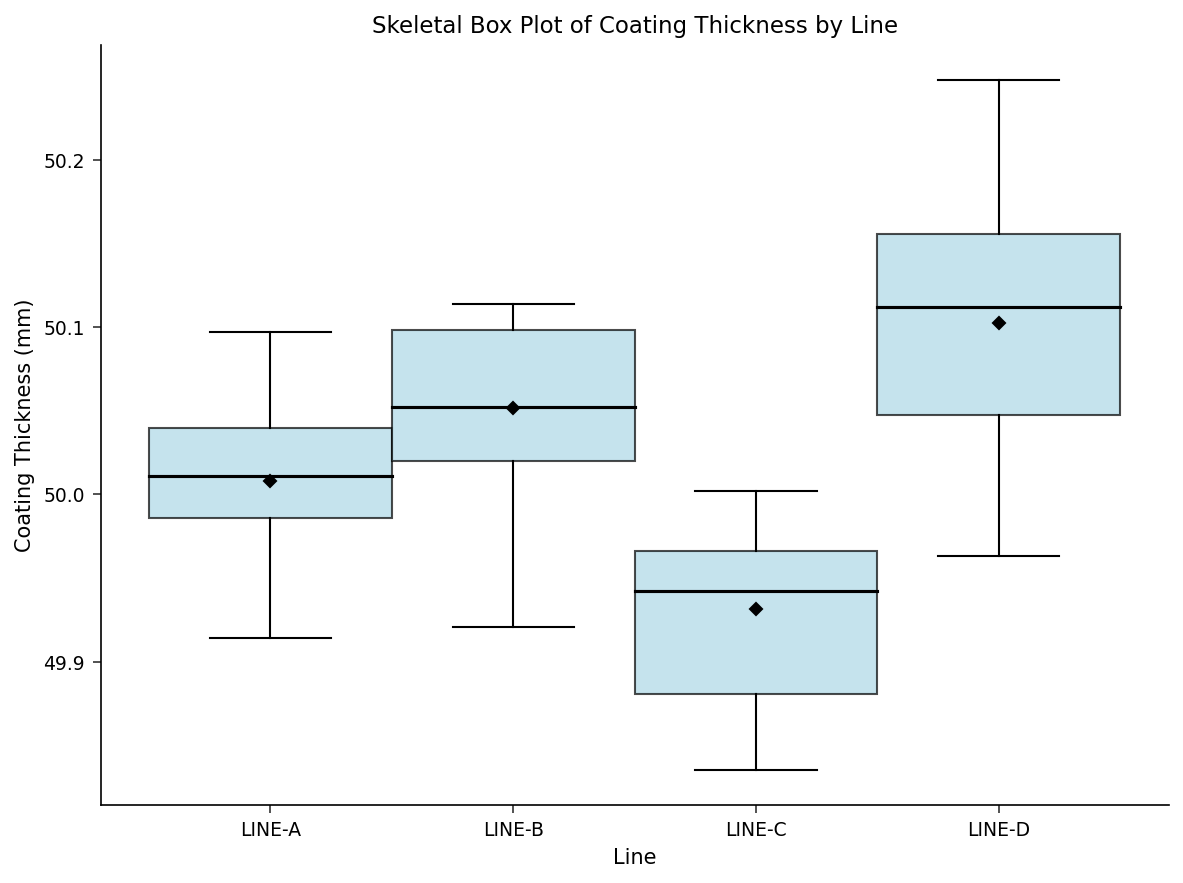

In [3]:
TÍTULO 'Skeletal Box Plot of Coating Thickness by Line';
PROCEDIMENTO boxplot DADOS=ProcessMeas;
   PLOT Thickness*Line;
EXECUTAR;

## Passo 4 — Diagrama de caixa esquemático

Mudamos para `BOXSTYLE=SCHEMATIC`. No estilo esquemático, cada bigode é limitado à observação mais extrema ainda dentro das cercas de 1.5 × IQR, e qualquer ponto para além de uma cerca é desenhado como um marcador de valor atípico individual. Nesta amostra, nenhuma linha tem um valor atípico dentro das cercas — a dispersão de cada linha é suficientemente compacta para que os bigodes atinjam o mínimo e o máximo verdadeiros — pelo que o gráfico esquemático se parece com o esquelético, o que é em si um resultado útil: diz ao engenheiro que nenhuma das quatro linhas está a produzir peças extremas. Os corpos das caixas continuam a tornar os desvios de linha para linha óbvios num relance, e o Passo 5 quantifica-os em relação aos limites de especificação.

                                  SPC Schematic Box Plot of Coating Thickness by Line                                   

                                  SPC Schematic Box Plot of Coating Thickness by Line

                                                 The BOXPLOT Procedure

Schematic Plots for Coating Thickness (mm)

Line                  N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10     

NOTE: Option TITLE changed to SPC Schematic Box Plot of Coating Thickness by Line.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


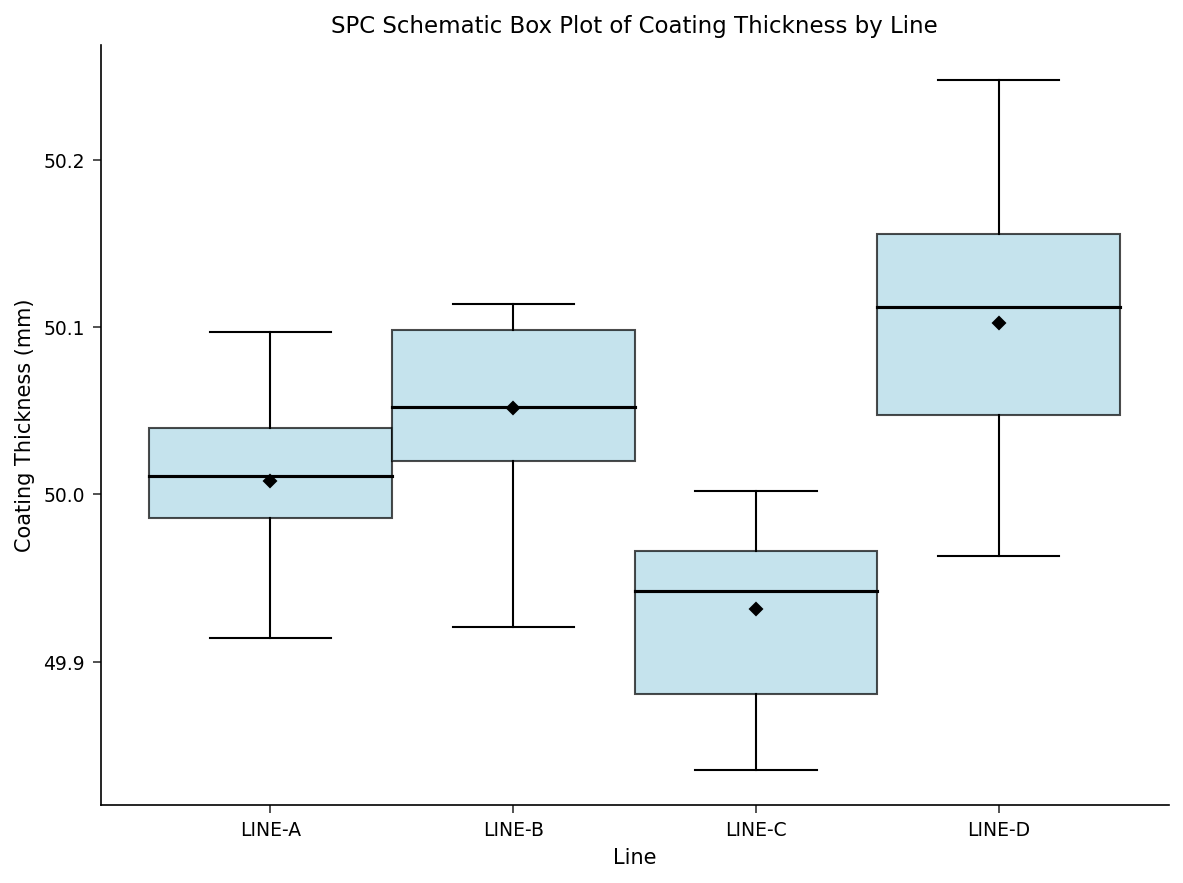

In [4]:
TÍTULO 'SPC Schematic Box Plot of Coating Thickness by Line';
PROCEDIMENTO boxplot DADOS=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
EXECUTAR;

## Passo 5 — Exportar estatísticas de caixa e avaliar em relação aos limites de especificação

A opção `OUTBOX=` captura cada estatística de caixa calculada para um conjunto de dados — para cada linha: o bigode inferior (`L`), Q1 (`1`), a média (`X`), a mediana (`M`), Q3 (`3`), o bigode superior (`H`), o desvio-padrão (`S`) e N. Este é o registo numérico de que um auditor necessita por detrás da imagem, e é também a forma mais limpa de verificar cada linha em relação à especificação de 49.80 / 50.20 mm. Ativamos `GRID` para facilitar a leitura, exportamos `BoxStats`, imprimimo-lo e, em seguida, executamos um curto passo DATA que sinaliza qualquer linha cujo intervalo de bigodes ultrapasse um limite de especificação.

                                   Schematic Box Plot with Grid and Statistics Export                                   

                                   Schematic Box Plot with Grid and Statistics Export

                                                 The BOXPLOT Procedure

Schematic Plots for Coating Thickness (mm)

Line                  N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10     

NOTE: Option TITLE changed to Schematic Box Plot with Grid and Statistics Export.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Computed Box Statistics (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Spec-Limit Assessment by Line.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


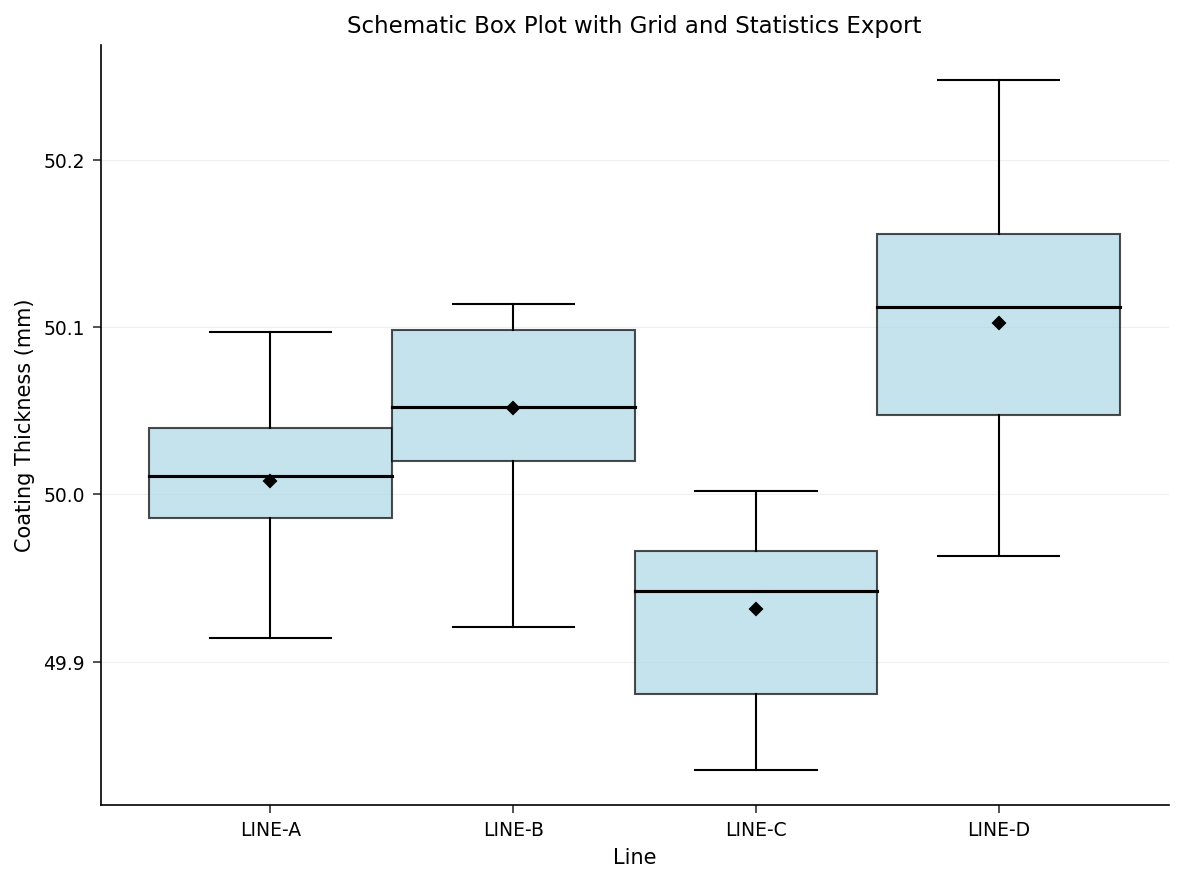

In [5]:
TÍTULO 'Schematic Box Plot with Grid and Statistics Export';
PROCEDIMENTO boxplot DADOS=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
EXECUTAR;

TÍTULO 'Computed Box Statistics (OUTBOX=)';
PROCEDIMENTO IMPRIMIR DADOS=BoxStats noobs;
EXECUTAR;

/* Assess each line against the 49.80 / 50.20 mm specification    */
/* using the exported whisker endpoints (THICKNESSL = low whisker, */
/* THICKNESSH = high whisker).                                     */
DADOS SpecCheck;
   DEFINIR BoxStats;
   COMPRIMENTO Status $40;
   LSL = 49.80;
   USL = 50.20;
   SE THICKNESSH > USL ENTÃO Status = 'High parts exceed USL';
   SENÃO SE THICKNESSL < LSL ENTÃO Status = 'Low parts below LSL';
   SENÃO Status = 'Within spec';
   MANTER LINE THICKNESSL THICKNESSH LSL USL Status;
EXECUTAR;

TÍTULO 'Spec-Limit Assessment by Line';
PROCEDIMENTO IMPRIMIR DADOS=SpecCheck noobs;
EXECUTAR;

## Passo 6 — Persistir um histórico de monitorização e voltar a desenhar a partir dele

No SPC contínuo, raramente se reanalisa cada medição bruta. `OUTHISTORY=` escreve uma linha de resumo por linha de produção (o mesmo layout que `HISTORY=` consome), pelo que os pesados dados brutos podem ser arquivados. Abaixo exportamos `LineHistory`, imprimimo-lo e, em seguida, provamos o ciclo completo alimentando-o diretamente de volta num novo `PROC BOXPLOT` via `HISTORY=` — exatamente como um painel diário reutilizaria estatísticas de subgrupo pré-agregadas.

                                                Export Subgroup History                                                 

                                                Export Subgroup History

                                                 The BOXPLOT Procedure

Schematic Plots for Coating Thickness (mm)

Line                  N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
-----

NOTE: Option TITLE changed to Export Subgroup History.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Summary History Dataset (one row per line).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to Box Plot Reconstructed from Summary History.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


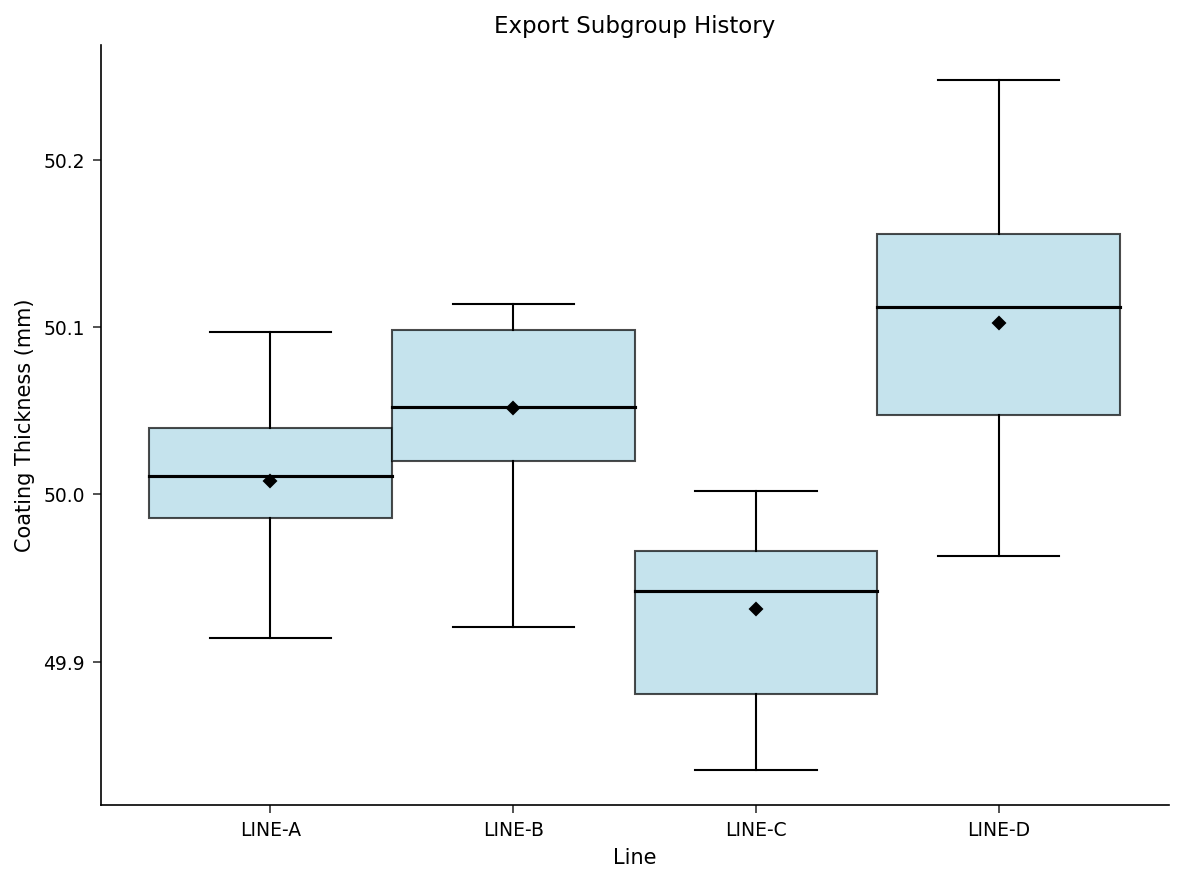

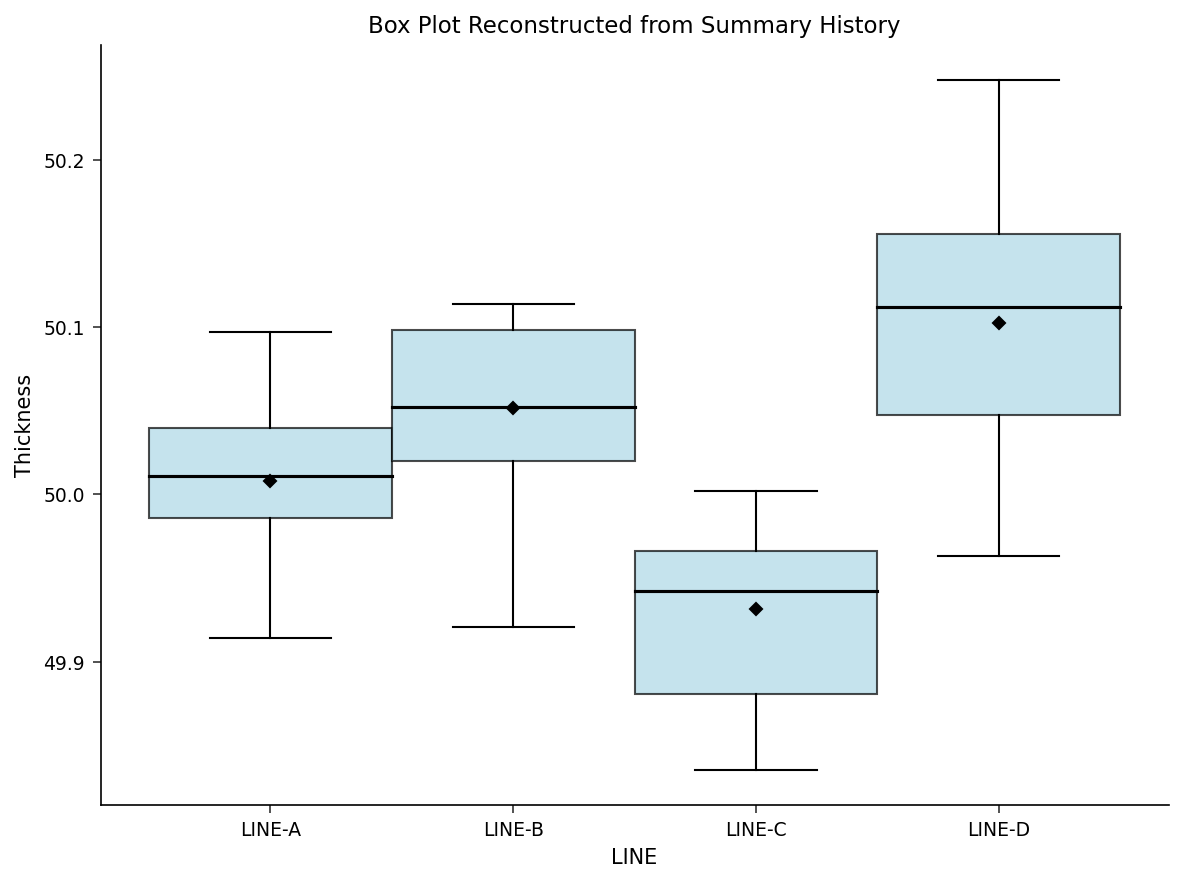

In [6]:
TÍTULO 'Export Subgroup History';
PROCEDIMENTO boxplot DADOS=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
EXECUTAR;

TÍTULO 'Summary History Dataset (one row per line)';
PROCEDIMENTO IMPRIMIR DADOS=LineHistory noobs;
EXECUTAR;

TÍTULO 'Box Plot Reconstructed from Summary History';
PROCEDIMENTO boxplot history=LineHistory;
   PLOT Thickness*Line;
EXECUTAR;

## Interpretar os resultados

Lendo os diagramas de caixa juntamente com o perfil de `PROC MEANS`, a tabela `OUTBOX=` e a avaliação dos limites de especificação:

- **Centragem.** A `LINE-A` está mais bem centrada no alvo de 50.00 mm (média 50.008 mm, mediana 50.011 mm). A `LINE-B` corre ligeiramente alta (média 50.052 mm). A `LINE-C` corre baixa (média 49.932 mm, mediana 49.942 mm), a linha a desviar-se em direção ao LSL. A `LINE-D` corre alta (média 50.102 mm, mediana 50.112 mm), a linha mais próxima do USL.
- **Dispersão.** A `LINE-D` apresenta a caixa mais larga e os bigodes mais longos — o seu desvio-padrão de 0.080 mm é aproximadamente 60–80% maior do que o das outras três linhas (0.045–0.051 mm), assinalando-a como a linha menos estável e a melhor candidata para um estudo de redução de variação. A `LINE-A` é a mais apertada (desvio-padrão 0.045 mm).
- **Caudas.** No estilo esquemático, nenhuma linha produz um valor atípico dentro das cercas: cada bigode atinge o mínimo/máximo verdadeiro da sua linha, pelo que o processo não está a produzir peças extremas isoladas. As diferenças de dispersão são impulsionadas pelo grosso de cada distribuição, e não por pontos dispersos.
- **Conformidade com a especificação.** Os extremos dos bigodes de `OUTBOX=`, avaliados em relação a 49.80 / 50.20 mm, colocam a `LINE-A`, a `LINE-B` e a `LINE-C` totalmente **dentro da especificação**. A `LINE-D` é a exceção: o seu bigode superior atinge **50.248 mm**, para além do **USL de 50.20 mm** — as peças altas na `LINE-D` excedem a especificação superior.
- **Operacionalização.** O conjunto de dados `OUTBOX=` dá aos auditores os quartis exatos, os extremos dos bigodes, a média e o desvio-padrão por detrás da imagem, e `OUTHISTORY=` fornece um resumo compacto de uma linha por linha de produção, passível de voltar a ser desenhado (Passo 6), para que o gráfico possa ser regenerado de forma programada sem reter as medições brutas — o diagrama de caixa reconstruído a partir do resumo é idêntico ao desenhado a partir dos dados brutos.

**Itens de ação:** priorizar a `LINE-D` — recentrá-la para baixo em direção ao alvo e lançar um estudo de redução de variação para puxar o seu bigode superior de volta para dentro do USL; empurrar a `LINE-C` para cima em direção ao alvo antes que a sua cauda inferior atinja o LSL; a `LINE-A` e a `LINE-B` estão a funcionar de forma aceitável.